# Prebuilt ReAct Agent - Human-In-The-Loop

![HITL Trade Execution](images/hitl_trade_execution.png)

c:\Users\aziz_\Documents\Projects\langgraph-advanced\.venv-1\Lib\site-packages\langgraph\checkpoint\serde\encrypted.py:5: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


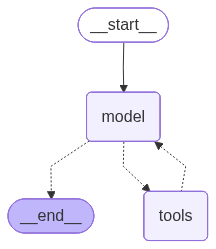

In [1]:
import os

import requests
import yfinance as yf
from pprint import pformat
from langchain_core.tools import tool
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI
from IPython.display import Image, display

@tool("lookup_stock")
def lookup_stock_symbol(company_name: str) -> str:
    """
    Converts a company name to its stock symbol using a financial API.

    Parameters:
        company_name (str): The full company name (e.g., 'Tesla').

    Returns:
        str: The stock symbol (e.g., 'TSLA') or an error message.
    """
    api_url = "https://www.alphavantage.co/query"
    params = {
        "function": "SYMBOL_SEARCH",
        "keywords": company_name,
        "apikey": os.getenv("ALPHAVANTAGE_API_KEY")
    }
    
    response = requests.get(api_url, params=params)
    data = response.json()
    
    if "bestMatches" in data and data["bestMatches"]:
        return data["bestMatches"][0]["1. symbol"]
    else:
        return f"Symbol not found for {company_name}."


@tool("fetch_stock_data")
def fetch_stock_data_raw(stock_symbol: str) -> dict:
    """
    Fetches comprehensive stock data for a given symbol and returns it as a combined dictionary.

    Parameters:
        stock_symbol (str): The stock ticker symbol (e.g., 'TSLA').
        period (str): The period to analyze (e.g., '1mo', '3mo', '1y').

    Returns:
        dict: A dictionary combining general stock info and historical market data.
    """
    period = "1mo"
    try:
        stock = yf.Ticker(stock_symbol)

        # Retrieve general stock info and historical market data
        stock_info = stock.info  # Basic company and stock data
        stock_history = stock.history(period=period).to_dict()  # Historical OHLCV data

        # Combine both into a single dictionary
        combined_data = {
            "stock_symbol": stock_symbol,
            "info": stock_info,
            "history": stock_history
        }

        return pformat(combined_data)

    except Exception as e:
        return {"error": f"Error fetching stock data for {stock_symbol}: {str(e)}"}

system_message = """
You are a financial advisor assistant. Use the provided tools to ground your answers
in up-to-date market data. Be concise, factual, and risk-aware.

Be decisive: when you have sufficient information to act, proceed with tool calls without
asking for confirmation. Only if information is missing or uncertain, ask a concise 
clarifying question.

When preparing or describing actions, include appropriate parameters (e.g., symbol, shares,
limit price, budgets) based on available data. Do not fabricate numbers or facts.
"""

@tool
def place_order(
    symbol: str,
    action: str,
    shares: int,
    limit_price: float,
    order_type: str = "limit",
) -> dict:
    """
    Execute a stock order.

    Parameters:
    - symbol: Ticker
    - action: "buy" or "sell"
    - shares: Number of shares to trade (pre-computed by the agent)
    - limit_price: Limit price per share
    - order_type: Order type, default "limit"

    Returns:
    - status: Execution result (simulated)
    - symbol
    - shares
    - limit_price
    - total_spent
    - type: Order type used
    - action
    """
    total_spent = round(int(shares) * limit_price, 2)
    return {
        "status": "filled",
        "symbol": symbol,
        "shares": int(shares),
        "limit_price": limit_price,
        "total_spent": total_spent,
        "type": order_type,
        "action": action,
    }

agent = create_agent(
    model=ChatOpenAI(model="gpt-4o-mini"),
    tools=[lookup_stock_symbol, fetch_stock_data_raw, place_order],
    system_prompt=system_message
)

display(Image(agent.get_graph().draw_mermaid_png()))

In [16]:
# Import OpenAI API key helper and set environment variable
from helper import get_openai_api_key
openai_api_key = get_openai_api_key()

import os

os.environ["OPENAI_API_KEY"] = get_openai_api_key()

## HITL with a Static Pause

`interrupt_before` / `interrupt_after` (compile‑time, always stop at those nodes)

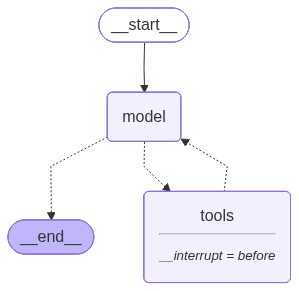

In [2]:
agent = create_agent(
    model=ChatOpenAI(model="gpt-4o-mini"),
    tools=[lookup_stock_symbol, fetch_stock_data_raw, place_order],
    system_prompt=system_message,

    interrupt_before=["tools"]
)

display(Image(agent.get_graph().draw_mermaid_png()))

## HITL with a Dynamic Pause

1. Use `interrupt()` to raise a `NodeInterrupt` when a condition is met. The most natural place to decide that in a prebuilt agent is `post_model_hook`, because it runs right after the LLM proposes the next action (including tool calls) but before tools execute. 

2. Resume the paused run by supplying the human decision via `Command(resume=...)`, with a checkpointer enabled to persist and resume state.

### Interruption on risky tools

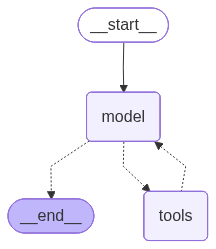

In [5]:
from langgraph.checkpoint.memory import InMemorySaver
from langchain.agents import create_agent, AgentState
from langchain_openai import ChatOpenAI
from IPython.display import Image, display
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage
from langgraph.types import interrupt
from langgraph.graph import StateGraph, START, END

RISKY_TOOLS = {"place_order"}

def halt_on_risky_tools(state: AgentState):
    last = state["messages"][-1]
    if isinstance(last, AIMessage) and getattr(last, "tool_calls", None):
        for tc in last.tool_calls:
            if tc.get("name") in RISKY_TOOLS:
                _ = interrupt({"awaiting": tc["name"], "args": tc.get("args", {})})

    return {}

agent = create_agent(
    model=ChatOpenAI(model="gpt-4o-mini"),
    tools=[lookup_stock_symbol, fetch_stock_data_raw, place_order],
    system_prompt=system_message,
    checkpointer=InMemorySaver()
)


builder = StateGraph(AgentState)
builder.add_node("agent", agent)
builder.add_node("post_processing", halt_on_risky_tools)  

builder.add_edge(START, "agent")
builder.add_edge("agent", "post_processing")    
builder.add_edge("post_processing", END)

display(Image(agent.get_graph().draw_mermaid_png()))

In [6]:
config = {"configurable": {"thread_id": "1"}}

response = agent.invoke({"messages": [HumanMessage(content="Buy $1000 of Tesla stock at the current price.")]}, config)
for message in response['messages']:
    message.pretty_print()

================================ Human Message =================================

Buy $1000 of Tesla stock at the current price.
================================== Ai Message ==================================
Tool Calls:
  lookup_stock (call_EEmytkxr5vqXpRA02p9DyzlN)
 Call ID: call_EEmytkxr5vqXpRA02p9DyzlN
  Args:
    company_name: Tesla
================================= Tool Message =================================
Name: lookup_stock

0R0X.LON
================================== Ai Message ==================================
Tool Calls:
  fetch_stock_data (call_dtn67oGUZ05vWls9ne50zJ7g)
 Call ID: call_dtn67oGUZ05vWls9ne50zJ7g
  Args:
    stock_symbol: 0R0X.LON
================================= Tool Message =================================
Name: fetch_stock_data

{"error": "Error fetching stock data for 0R0X.LON: HTTP Error 404: "}
================================== Ai Message ==================================
Tool Calls:
  lookup_stock (call_LVm3Ji7l7dC0utpQa2JJkKnT)
 Call ID: call_

In [7]:
state = agent.get_state(config)
state.next

()

In [8]:
"__interrupt__" in response

False

In [10]:
interrupts = response.get("__interrupt__", [])
for intr in interrupts:
    print("Interrupted:", intr.id, intr.value)

In [12]:
# def print_tool_approval(payload):
#     tool = payload.get("awaiting", "unknown_tool")
#     args = payload.get("args", {})

#     print("—-- Approval needed —--")
#     print(f"Tool: {tool}")

#     if isinstance(args, dict) and args:
#         print("Parameters:")
#         for k, v in args.items():
#             print(f"  - {k}: {v}")
#     elif args:
#         print(f"Parameters: {args}")
#     else:
#         print("No parameters.")

# print_tool_approval(interrupts[0].value)

def print_tool_approval(interrupt_value):
    # ✅ tool call is nested under "tool_call" key
    tool_call = interrupt_value.get("tool_call", {})
    
    tool = tool_call.get("name", "unknown_tool")
    args = tool_call.get("args", {})

    print("--- Approval needed ---")
    print(f"Tool: {tool}")

    if isinstance(args, dict) and args:
        print("Parameters:")
        for k, v in args.items():
            print(f"  - {k}: {v}")
    elif args:
        print(f"Parameters: {args}")
    else:
        print("No parameters.")

# ✅ Safe call with guard
interrupts = response.get("__interrupt__", [])

if interrupts:
    print_tool_approval(interrupts[0].value)
else:
    print("No interrupts found.")

No interrupts found.


### Resuming the graph

In [17]:
from langgraph.types import Command

response = agent.invoke(Command(resume={"approved": True}), config=config)
for message in response['messages']:
    message.pretty_print()

================================ Human Message =================================

Buy $1000 of Tesla stock at the current price.
================================== Ai Message ==================================
Tool Calls:
  lookup_stock (call_llN03IKf7ncsBXB5KJIrTB83)
 Call ID: call_llN03IKf7ncsBXB5KJIrTB83
  Args:
    company_name: Tesla
================================= Tool Message =================================
Name: lookup_stock

0R0X.LON
================================== Ai Message ==================================
Tool Calls:
  fetch_stock_data (call_XMc2GRvJ3v1UScSnKDXy4E37)
 Call ID: call_XMc2GRvJ3v1UScSnKDXy4E37
  Args:
    stock_symbol: 0R0X.LON
================================= Tool Message =================================
Name: fetch_stock_data

{"error": "Error fetching stock data for 0R0X.LON: HTTP Error 404: "}
================================== Ai Message ==================================
Tool Calls:
  lookup_stock (call_Lwpc56oXk4jTmVxbiZb046Hs)
 Call ID: call_

### Approving or Declining Risky Tools

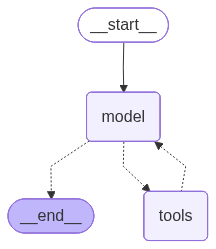

In [14]:
def halt_on_risky_tools(state: AgentState):
    last = state["messages"][-1]
    if isinstance(last, AIMessage) and getattr(last, "tool_calls", None):
        for tc in last.tool_calls:
            if tc.get("name") in RISKY_TOOLS:
                decision = interrupt({"awaiting": tc["name"], "args": tc.get("args", {})})

                # tool approved
                if isinstance(decision, dict) and decision.get("approved"):
                    return {}

                # tool rejected
                tool_msg = ToolMessage(
                    content=f"Cancelled by human. Continue without executing that tool and provide next steps.",
                    tool_call_id=tc["id"],
                    name=tc["name"]
                )
                return {"messages": [tool_msg]}

    return {}


agent = create_agent(
    model=ChatOpenAI(model="gpt-4o-mini"),
    tools=[lookup_stock_symbol, fetch_stock_data_raw, place_order],
    system_prompt=system_message,
    checkpointer=InMemorySaver()

    # version="v2",
    # post_model_hook=halt_on_risky_tools
)

builder = StateGraph(AgentState)
builder.add_node("agent", agent)
builder.add_node("post_processing", halt_on_risky_tools)  

builder.add_edge(START, "agent")
builder.add_edge("agent", "post_processing")    
builder.add_edge("post_processing", END)

display(Image(agent.get_graph().draw_mermaid_png()))

### Testing Approval

In [15]:
config = {"configurable": {"thread_id": "1"}}

response = agent.invoke({"messages": [HumanMessage(content="Buy $1000 of Tesla stock at the current price.")]}, config)
for message in response['messages']:
    message.pretty_print()

================================ Human Message =================================

Buy $1000 of Tesla stock at the current price.
================================== Ai Message ==================================
Tool Calls:
  lookup_stock (call_llN03IKf7ncsBXB5KJIrTB83)
 Call ID: call_llN03IKf7ncsBXB5KJIrTB83
  Args:
    company_name: Tesla
================================= Tool Message =================================
Name: lookup_stock

0R0X.LON
================================== Ai Message ==================================
Tool Calls:
  fetch_stock_data (call_XMc2GRvJ3v1UScSnKDXy4E37)
 Call ID: call_XMc2GRvJ3v1UScSnKDXy4E37
  Args:
    stock_symbol: 0R0X.LON
================================= Tool Message =================================
Name: fetch_stock_data

{"error": "Error fetching stock data for 0R0X.LON: HTTP Error 404: "}
================================== Ai Message ==================================
Tool Calls:
  lookup_stock (call_Lwpc56oXk4jTmVxbiZb046Hs)
 Call ID: call_

In [ ]:
interrupts = response["__interrupt__"]
print_tool_approval(interrupts[0].value)

In [ ]:
from langgraph.types import Command

response = agent.invoke(Command(resume={"approved": True}), config=config)
for message in response['messages']:
    message.pretty_print()

In [ ]:
"__interrupt__" in response

### Testing Canceling

In [ ]:
config = {"configurable": {"thread_id": "2"}}

response = agent.invoke({"messages": [HumanMessage(content="Buy $1000 of nvidia stock at the current price.")]}, config)
for message in response['messages']:
    message.pretty_print()

In [ ]:
interrupts = response["__interrupt__"]
print_tool_approval(interrupts[0].value)

In [ ]:
response = agent.invoke(Command(resume={"approved": False}), config=config)
for message in response['messages']:
    message.pretty_print()

In [ ]:
"__interrupt__" in response

## Reference Links

**1. LangGraph create_react_agent API Reference**

https://langchain-ai.github.io/langgraph/reference/agents/#langgraph.prebuilt.chat_agent_executor.create_react_agent

→ Technical reference for the create_react_agent function, including parameters, return types, and implementation details.